## Definitions

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import categorical_crossentropy

## Load and format data

In [2]:
def plot_random_examples(x_data, y_data, num_examples=100):
    # Select random indices
    idx = np.random.choice(len(x_data), num_examples, replace=False)
    selected_images = x_data[idx]
    selected_labels = y_data[idx]

    # Create a 3x3 grid plot
    fig, axes = plt.subplots(10, 10, figsize=(6,6))
    axes = axes.flatten()

    for img, label, ax in zip(selected_images, selected_labels, axes):
        ax.imshow(img, cmap='gray')
        #ax.set_title(f"Label: {label}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

In [3]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

Number of classes: 10
Example of pixelated images of animals: 



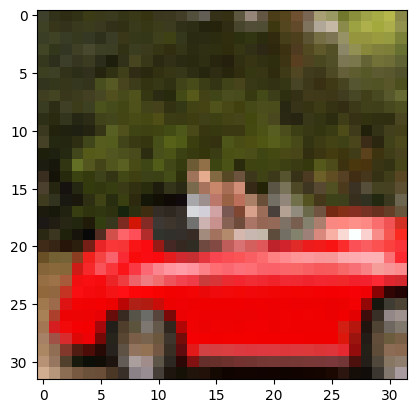

Class: [1]



In [4]:
num_cls = len(np.unique(y_train))
print('Number of classes: ' + str(num_cls))

print('Example of pixelated images of animals: \n')

k = 99
plt.imshow(np.squeeze(x_train[k,:,:]))
plt.show()
print('Class: '+str(y_train[k])+'\n')

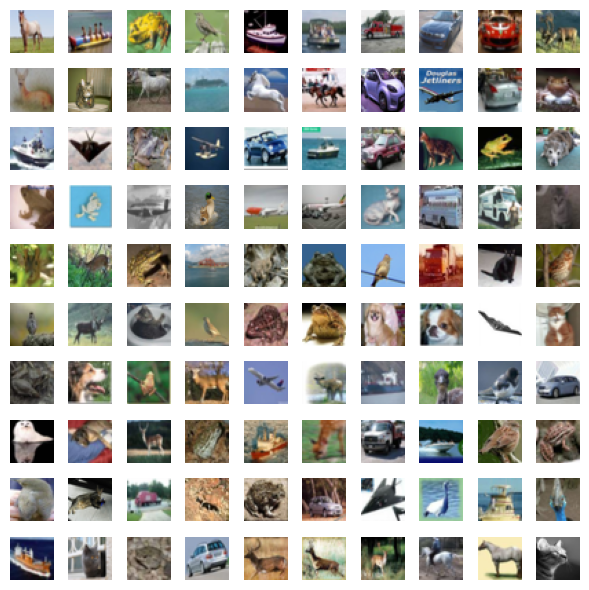

In [5]:
plot_random_examples(x_train, y_train, num_examples=100)

In [6]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

y_train = to_categorical(y_train, num_cls)
y_test = to_categorical(y_test, num_cls)

print('Shape of x_train: '+str(x_train.shape))
print('Shape of y_train: '+str(y_train.shape))

Shape of x_train: (50000, 32, 32, 3)
Shape of y_train: (50000, 10)


## Training

In [9]:
# Model parameters
model_name = 'CNN_CIFAR10-2'

pweight = f'./weights/weights_{model_name}.keras'

if not os.path.exists('./weights'):
    os.mkdir('./weights')


## EXPLORE VALUES AND FIND A GOOD SET
b_size = 128
val_split = 0.1
ep = 20

In [ ]:
# Define model
input_shape = x_train.shape[1:]  # (32, 32, 3)

model = Sequential()

model.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=input_shape))
model.add(BatchNormalization())
model.add(Conv2D(32, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(num_cls, activation='softmax'))

model.compile(loss=categorical_crossentropy,
              optimizer=Adam(learning_rate=0.001),
              metrics=['accuracy'])

model.summary()

checkpointer = ModelCheckpoint(filepath=pweight, verbose=1, save_best_only=True)
early_stop = EarlyStopping(patience=8, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(factor=0.5, patience=4, verbose=1)
callbacks_list = [checkpointer, early_stop, reduce_lr]

history=model.fit(x_train, y_train,
                        epochs=ep,
                        batch_size=b_size,
                        verbose=1,
                        shuffle=True,
                        validation_split = val_split,
                        callbacks=callbacks_list)

print('CNN weights saved in ' + pweight)

# Plot loss vs epochs
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.show()

# Plot accuracy vs epochs
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,171,178 (8.28 MB)

 Trainable params: 2,169,770 (8.28 MB)

 Non-trainable params: 1,408 (5.50 KB)

Epoch 1/20
351/352 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.4023 - loss: 1.9807
Epoch 1: val_loss improved from inf to 2.56589, saving model to ./weights/weights_CNN_CIFAR10-2.keras
352/352 ━━━━━━━━━━━━━━━━━━━━ 30s 83ms/step - accuracy: 0.4028 - loss: 1.9784 - val_accuracy: 0.2368 - val_loss: 2.5659 - learning_rate: 0.0010
Epoch 2/20
351/352 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.6231 - loss: 1.0648
Epoch 2: val_loss improved from 2.56589 to 1.10674, saving model to ./weights/weights_CNN_CIFAR10-2.keras
352/352 ━━━━━━━━━━━━━━━━━━━━ 30s 85ms/step - accuracy: 0.6232 - loss: 1.0645 - val_accuracy: 0.6196 - val_loss: 1.1067 - learning_rate: 0.0010
Epoch 3/20
351/352 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.6872 - loss: 0.8828
Epoch 3: val_loss improved from 1.10674 to 0.88505, saving model to ./weights/weights_CNN_CIFAR10-2.keras
352/352 ━━━━━━━━━━━━━━━━━━━━ 30s 85ms/step - accuracy: 0.6873 - loss: 0.8827 - val_accuracy: 0.7032 - val_loss: 0.8850 - learning_rate: 0.0

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,171,178 (8.28 MB)

 Trainable params: 2,169,770 (8.28 MB)

 Non-trainable params: 1,408 (5.50 KB)

Epoch 1/20
351/352 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.4023 - loss: 1.9807
Epoch 1: val_loss improved from inf to 2.56589, saving model to ./weights/weights_CNN_CIFAR10-2.keras
352/352 ━━━━━━━━━━━━━━━━━━━━ 30s 83ms/step - accuracy: 0.4028 - loss: 1.9784 - val_accuracy: 0.2368 - val_loss: 2.5659 - learning_rate: 0.0010
Epoch 2/20
351/352 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.6231 - loss: 1.0648
Epoch 2: val_loss improved from 2.56589 to 1.10674, saving model to ./weights/weights_CNN_CIFAR10-2.keras
352/352 ━━━━━━━━━━━━━━━━━━━━ 30s 85ms/step - accuracy: 0.6232 - loss: 1.0645 - val_accuracy: 0.6196 - val_loss: 1.1067 - learning_rate: 0.0010
Epoch 3/20
351/352 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.6872 - loss: 0.8828
Epoch 3: val_loss improved from 1.10674 to 0.88505, saving model to ./weights/weights_CNN_CIFAR10-2.keras
352/352 ━━━━━━━━━━━━━━━━━━━━ 30s 85ms/step - accuracy: 0.6873 - loss: 0.8827 - val_accuracy: 0.7032 - val_loss: 0.8850 - learning_rate: 0.0

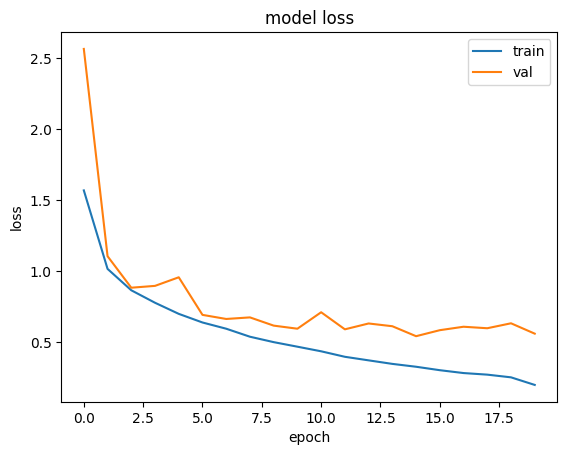

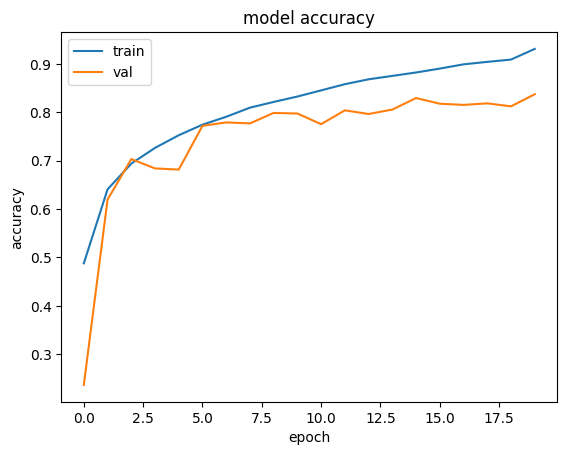

In [10]:
# Define model
input_shape = x_train.shape[1:]  # (32, 32, 3)

model = Sequential()

model.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=input_shape))
model.add(BatchNormalization())
model.add(Conv2D(32, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(num_cls, activation='softmax'))

model.compile(loss=categorical_crossentropy,
              optimizer=Adam(learning_rate=0.001),
              metrics=['accuracy'])

model.summary()

checkpointer = ModelCheckpoint(filepath=pweight, verbose=1, save_best_only=True)
early_stop = EarlyStopping(patience=8, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(factor=0.5, patience=4, verbose=1)
callbacks_list = [checkpointer, early_stop, reduce_lr]

history=model.fit(x_train, y_train,
                        epochs=ep,
                        batch_size=b_size,
                        verbose=1,
                        shuffle=True,
                        validation_split = val_split,
                        callbacks=callbacks_list)

print('CNN weights saved in ' + pweight)

# Plot loss vs epochs
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.show()

# Plot accuracy vs epochs
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

## Make predictions in test set

In [9]:
num_cls = len(y_test[0])
print('Number of classes: ' + str(num_cls))

print('Shape of x_test: '+str(x_test.shape)+'\n')

## Define model parameters
model_name='CNN_CIFAR10-2' # To compare models, you can give them different names
pweight='./weights/weights_' + model_name  + '.keras'

Number of classes: 10
Shape of x_test: (10000, 32, 32, 3)



In [10]:
# Evaluate on test set
model = load_model(pweight)
y_pred = np.argmax(model.predict(x_test), axis=1)
y_test_labels = np.argmax(y_test, axis=1)
Acc_pred = np.mean(y_pred == y_test_labels)
print('Accuracy on CIFAR-10 test set: {:.4f}'.format(Acc_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
Accuracy on CIFAR-10 test set: 0.8084
